<hr>

<h2 style="text-align:center; color:#1F618D;">
 House Price Prediction Project
</h2>

<br>

<table style="width:100%; border-collapse:collapse;">
<tr>
<td><b>Name:</b> Manya Kedia</td>
<td><b>Role:</b> Machine Learning Intern</td>
</tr>

<tr>
<td><b>Institute:</b> Thapar Institute of Engineering & Technology</td>
<td><b>Project:</b> House Price Prediction</td>
</tr>

<tr>
<td><b>Models Used:</b> Linear Regression, Random Forest</td>
<td><b>Tools:</b> Python, Pandas, Scikit-Learn, Seaborn</td>
</tr>
</table>

<br>

<p style="text-align:center; color:#566573;">
This project analyzes housing data, identifies key factors influencing property prices,
and evaluates multiple machine learning models to predict house prices accurately.
</p>

<hr>

<div style="background-color:#EBF5FB; padding:15px; border-radius:10px;">

<h3> Executive Summary</h3>

This project develops and evaluates machine learning models for predicting house prices based on property characteristics such as area, bedrooms, bathrooms, parking availability, and furnishing status. Multiple regression models were trained and compared using industry-standard evaluation metrics including MAE, RMSE, and R² Score. Feature importance analysis was performed to identify the most influential factors affecting property value.

</div>

In [1]:
import pandas as pd

df = pd.read_csv("Housing.csv")


<h2 style="color:#117A65;">
Project Objective
</h2>

This project aims to predict house prices using machine learning techniques and identify the key factors that influence property values.

<h2 style="background-color:#D6EAF8; padding:10px; border-radius:8px;">
Task 1: Data Loading & Exploration
</h2>

In [6]:
df.head(10)



,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [3]:
df.shape

(545, 13)

In [4]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

<h2 style="background-color:#D5F5E3; padding:10px; border-radius:8px;">
Task 2: Data Cleaning & Preprocessing
</h2>

In [7]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

### Missing Value Analysis

No missing values were found in the dataset. Therefore, no imputation techniques were required before model training.

In [8]:
df = df.drop_duplicates()

In [11]:
df = pd.get_dummies(df, drop_first=True)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   parking                          545 non-null    int64
 6   mainroad_yes                     545 non-null    bool 
 7   guestroom_yes                    545 non-null    bool 
 8   basement_yes                     545 non-null    bool 
 9   hotwaterheating_yes              545 non-null    bool 
 10  airconditioning_yes              545 non-null    bool 
 11  prefarea_yes                     545 non-null    bool 
 12  furnishingstatus_semi-furnished  545 non-null    b

<h2 style="background-color:#FCF3CF; padding:10px; border-radius:8px;">
Task 3: Model Building
</h2>

In [22]:
X = df.drop("price", axis=1)

y = df["price"]

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

<h3 style="color:#2874A6;">
Linear Regression Model
</h3>

In [24]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train);

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[ 235.97, 76778.7 ,1094444.79,..., 629890.57,-126881.82,-413645.06]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](13,)","['area','bedrooms','bathrooms',...,'prefarea_yes', 'furnishingstatus_semi-furnished','furnishingstatus_unfurnished']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.6e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(13)


In [25]:
y_pred_lr = lr.predict(X_test)

In [26]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae_lr = mean_absolute_error(y_test, y_pred_lr)

rmse_lr = mean_squared_error(
    y_test,
    y_pred_lr
) ** 0.5

r2_lr = r2_score(
    y_test,
    y_pred_lr
)

print(mae_lr)
print(rmse_lr)
print(r2_lr)

970043.4039201637
1324506.9600914388
0.6529242642153184


<h3 style="color:#196F3D;">
 Random Forest Regressor
</h3>

In [27]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train);

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [28]:
y_pred_rf = rf.predict(X_test)

In [29]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = mean_squared_error(
    y_test,
    y_pred_rf
) ** 0.5

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

print(mae_rf)
print(rmse_rf)
print(r2_rf)

1021546.0353211008
1400565.9728553821
0.611918531405699


<h2 style="background-color:#FADBD8; padding:10px; border-radius:8px;">
 Model Performance Comparison
</h2>

In [30]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        mae_lr,
        mae_rf
    ],
    "RMSE": [
        rmse_lr,
        rmse_rf
    ],
    "R2": [
        r2_lr,
        r2_rf
    ]
})

,Model,MAE,RMSE,R2
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.021546e+06,1.400566e+06,0.611919


### Model Comparison Analysis

Although Random Forest is generally considered a more powerful machine learning algorithm, Linear Regression achieved better performance on this dataset. This suggests that the relationship between housing features and price is relatively linear and can be effectively modeled without complex non-linear decision boundaries. Additionally, the dataset contains only 545 observations, which may limit the advantages of ensemble-based methods such as Random Forest.

<h2 style="background-color:#FCF3CF; padding:10px; border-radius:8px;">
Task 4: Data Visualisation & Analysis
</h2>

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))



<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<h3 style="color:#7D3C98;">
Distribution of House Prices
</h3>

Task was destroyed but it is pending!
task: <Task pending name='Task-314' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\manya\AppData\Roaming\Python\Python312\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-315' coro=<Kernel.shell_main() running at C:\Users\manya\AppData\Roaming\Python\Python312\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\manya\AppData\Roaming\Python\Python312\site-packages\zmq\eventloop\zmqstream.py:563]>
C:\Users\manya\AppData\Roaming\Python\Python312\site-packages\matplotlib\artist.py:1263: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  for k, v in props.items():
Task was destroyed but it is pending!
task: <Task pending name='Task-315' coro=<Kernel.shell_main() running at C:\Users\manya\AppData\Roaming\Python\Python312\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]>


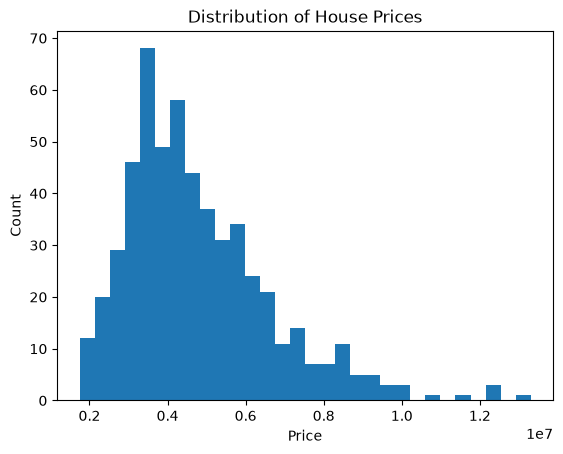

In [43]:
plt.hist(df["price"], bins=30)

plt.title("Distribution of House Prices")

plt.xlabel("Price")

plt.ylabel("Count")

plt.savefig("charts/histogram.png")

plt.show()

<h3 style="color:#7D3C98;">
 Correlation Heatmap
</h3>

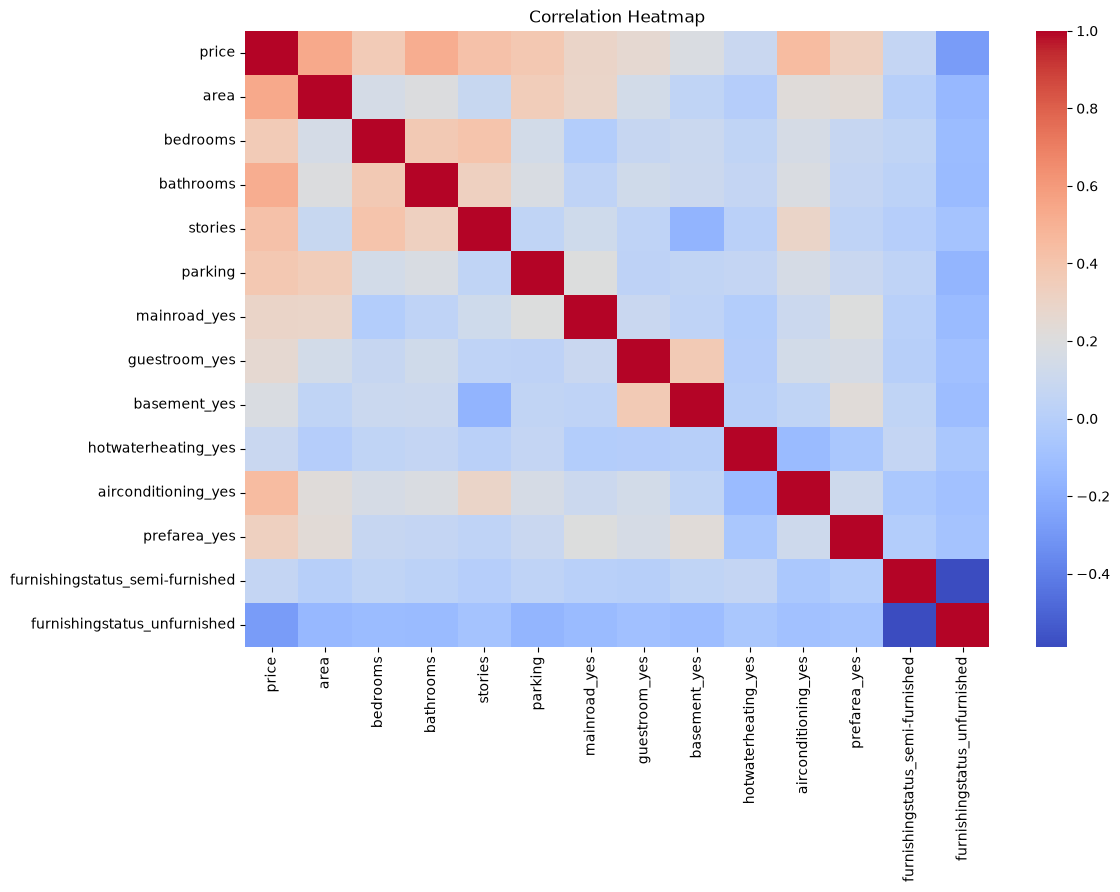

In [44]:
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(df.corr(),
            cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.savefig("charts/heatmap.png")

plt.show()

<h3 style="color:#7D3C98;">
 Actual vs Predicted Prices
</h3>

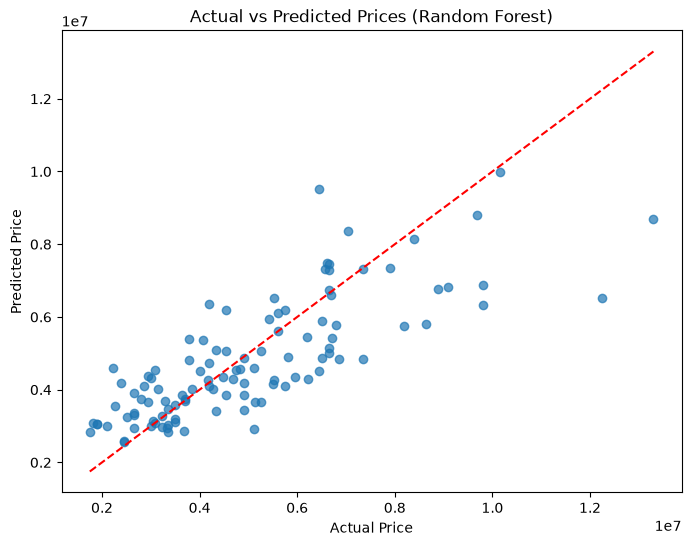

In [45]:
y_pred_rf = rf.predict(X_test)

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_rf, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices (Random Forest)")

plt.savefig("charts/prediction.png")
plt.show()

<h3 style="color:#7D3C98;">
 Feature Importance Analysis
</h3>

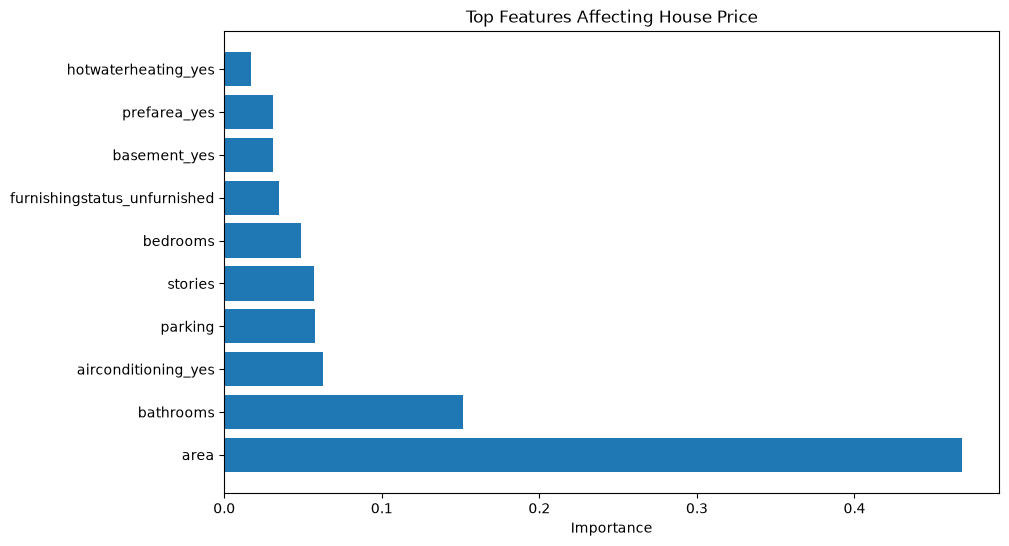

In [46]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))
plt.barh(
    importance['Feature'][:10],
    importance['Importance'][:10]
)

plt.xlabel("Importance")
plt.title("Top Features Affecting House Price")

plt.savefig("charts/feature_importance.png")
plt.show()

### Feature Importance Interpretation

The feature importance analysis indicates that area is the most influential factor affecting house prices, followed by bathrooms, parking availability, and other housing amenities. This suggests that larger properties with better facilities generally command higher market values.

### Task 5: Insights & Summary

The analysis showed that **area**, **bathrooms**, and **parking availability** were among the most influential factors affecting house prices, with area having the strongest impact. The Linear Regression model achieved an R² score of approximately **0.65**, meaning it was able to explain around 65% of the variation in house prices and provided reasonably accurate predictions. One surprising finding was that the Linear Regression model outperformed the Random Forest model, despite Random Forest generally being considered a more advanced algorithm. The correlation analysis also revealed that larger houses with more amenities tend to have significantly higher prices. Based on these findings, real estate businesses should focus on property size and key amenities when estimating prices and developing marketing strategies.


<div style="background-color:#E8F8F5; padding:15px; border-radius:10px;">

<h3> Key Results</h3>

<ul>
<li>Best Performing Model: Linear Regression Model</li>
<li>Most Important Feature: Area</li>
<li>Strongest Positive Correlation with Price: Area and Bathrooms</li>
<li>Model Evaluation Performed Using MAE, RMSE and R² Score</li>
</ul>

</div>

<div style="background-color:#FEF9E7; padding:15px; border-radius:10px;">

<h3> Business Recommendation</h3>

Real estate agencies should prioritize property size, bathroom count, parking availability, and premium amenities while determining listing prices. These features demonstrated the strongest influence on property value and can significantly improve pricing accuracy.

</div>

<hr>

<h3 style="text-align:center; color:#2E4053;">
 Project Completed Successfully
</h3>

<p style="text-align:center;">
Prepared by <b>Manya Kedia</b><br>
B.Tech Computer Science Engineering<br>
Thapar Institute of Engineering & Technology
</p>